In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
#for machine learning algorithms
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [50]:
import xgboost as xgb
import shap

In [51]:
df=pd.read_csv("gendergapinaverage new.csv")
print(df.head())
print(df.info())

  country Code  Year  Gender wage gap %
0  Brazil  BRA  1981              34.21
1  Brazil  BRA  1982              33.66
2  Brazil  BRA  1983              35.75
3  Brazil  BRA  1984              34.04
4  Brazil  BRA  1985              28.58
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            413 non-null    object 
 1   Code               413 non-null    object 
 2   Year               413 non-null    int64  
 3   Gender wage gap %  413 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 13.0+ KB
None


In [52]:
#Advanced preprocessing and Handling missing values

numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

if "gender_pay_gap" in numeric_features:
    numeric_features.remove("gender_pay_gap")

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [53]:
# For time based feature engineering
# global trend index (captures time effect)
df["year_normalized"] = df["Year"] - df["Year"].min()

# decade grouping
df["decade"] = (df["Year"] // 10) * 10

In [54]:
#Country-wise average gap
country_mean = df.groupby("country")["Gender wage gap %"].transform("mean")
df["country_avg_gap"] = country_mean

In [55]:
#Country wise inequality instability over time time
country_std = df.groupby("country")["Gender wage gap %"].transform("std")
df["country_gap_volatility"] = country_std

In [56]:
# Frequency Encoding for every country
code_freq = df["Code"].value_counts()
df["code_frequency"] = df["Code"].map(code_freq)

In [57]:
# Trend detecting feature to analyse if the gap is increasing or decreasing with time for every country
df["country_year_trend"] = df.groupby("country")["Gender wage gap %"].transform(
    lambda x: x.diff().fillna(0)
)

In [58]:
#Lag feature to check time dependency
df = df.sort_values(["country", "Year"])

df["gap_lag1"] = df.groupby("country")["Gender wage gap %"].shift(1)
df["gap_lag1"] = df["gap_lag1"].fillna(df["gap_lag1"].mean())

In [59]:
# Final features set
features = [
    "Year",
    "year_normalized",
    "decade",
    "country_avg_gap",
    "country_gap_volatility",
    "code_frequency",
    "country_year_trend",
    "gap_lag1"
]

X = df[features]
y = df["Gender wage gap %"]

In [60]:
#splitting the data for testing and training based on the year
train = df[df["Year"] < 2010]
test = df[df["Year"] >= 2010]

X_train = train[features]
y_train = train["Gender wage gap %"]

X_test = test[features]
y_test = test["Gender wage gap %"]

In [61]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [62]:
preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [63]:
model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror"
)

In [64]:
from sklearn.pipeline import Pipeline

final_model = Pipeline([
    ("preprocess", preprocess),
    ("model", model)
])

final_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.8, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=N...s=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [65]:
preds = final_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R2 Score:", r2_score(y_test, preds))

MAE: 2.150148135804361
R2 Score: 0.9083412698226995


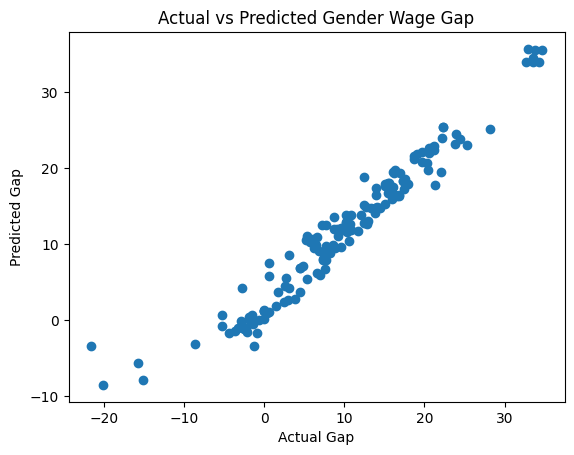

In [66]:
import matplotlib.pyplot as plt

plt.scatter(y_test, preds)
plt.xlabel("Actual Gap")
plt.ylabel("Predicted Gap")
plt.title("Actual vs Predicted Gender Wage Gap")
plt.show()

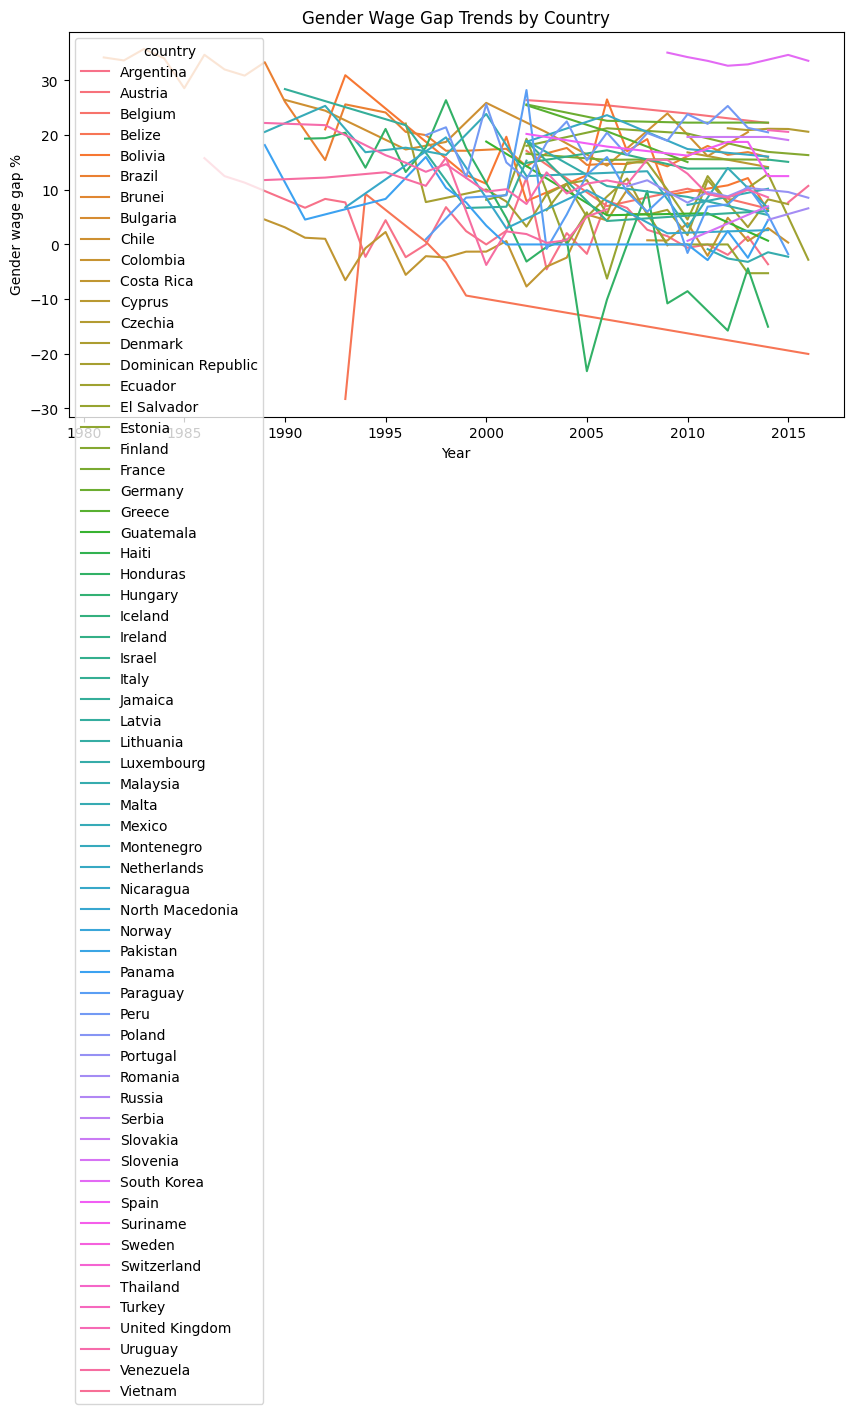

In [67]:
# Country wise trend over the years
import seaborn as sns

plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="Year", y="Gender wage gap %", hue="country")
plt.title("Gender Wage Gap Trends by Country")
plt.show()

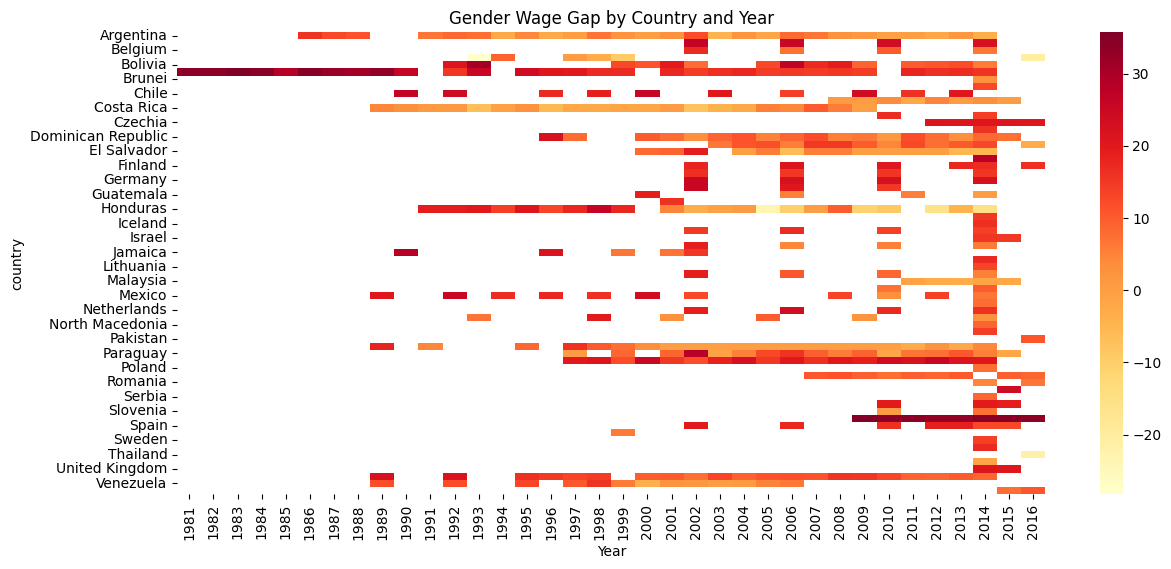

In [68]:
# Heatmap for analysing country vs year trends
pivot_df = df.pivot(
    index="country",
    columns="Year",
    values="Gender wage gap %"
)

plt.figure(figsize=(14,6))
sns.heatmap(pivot_df, cmap="YlOrRd")
plt.title("Gender Wage Gap by Country and Year")
plt.show()

In [69]:
df = df.rename(columns={
    "Gender wage gap %": "gap"
})

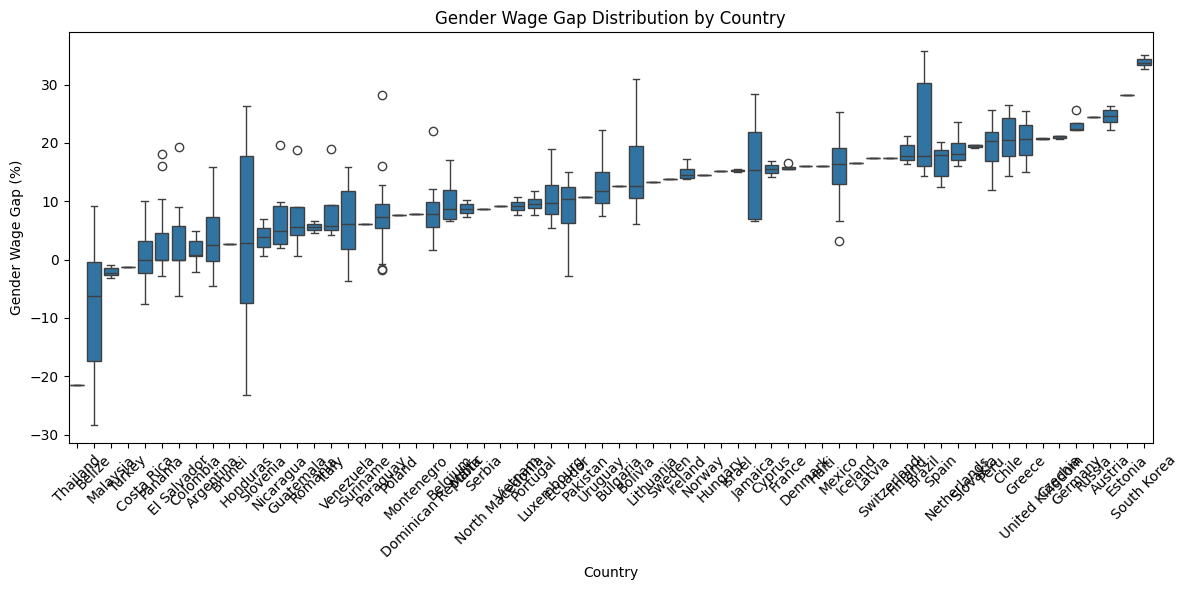

In [70]:
# Box plot - when there are are many years per country (sorted acc to median)
country_order = (
    df.groupby("country")["gap"]
      .median()
      .sort_values()
      .index
)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="country",
    y="gap",
    order=country_order
)

plt.title("Gender Wage Gap Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Gender Wage Gap (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()